In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv(r'D:\ML_InternetLearning\100_Days_ML\Data\placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Preprocessing the data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [10]:
df.shape

(100, 4)

In [11]:
df = df.iloc[:, 1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# EDA

In [12]:
import matplotlib.pyplot as plt

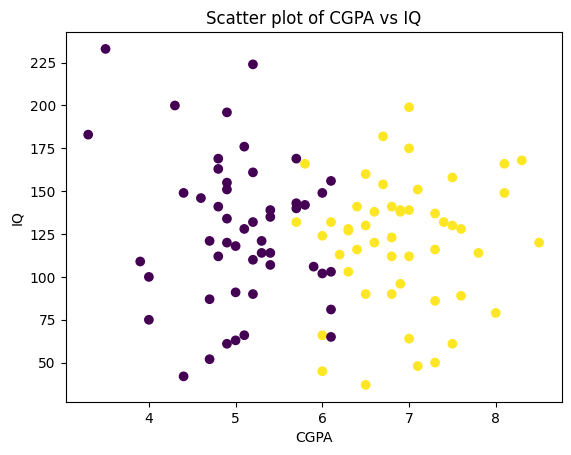

In [13]:
plt.scatter(df['cgpa'], df['iq'],c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Scatter plot of CGPA vs IQ')
plt.show()

# Yellow data points shows placement done and blue data points shows placement not done. 

# Selecting columns for model training


In [14]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [15]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [16]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

Train test split

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.1)

In [19]:
X_train

,cgpa,iq
59,4.8,112.0
83,7.5,130.0
93,6.8,112.0
42,7.6,89.0
57,6.5,130.0
...,...,...
0,6.8,123.0
80,4.9,196.0
9,5.1,66.0
11,6.9,138.0


In [20]:
Y_train

59    0
83    1
93    1
42    1
57    1
     ..
0     1
80    0
9     0
11    1
87    1
Name: placement, Length: 90, dtype: int64

In [21]:
# Scaling values from -1 to 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [22]:
X_train

array([[-1.0330985 , -0.29376337],
       [ 1.27216261,  0.15183275],
       [ 0.67450232, -0.29376337],
       [ 1.35754265, -0.8631362 ],
       [ 0.4183622 ,  0.15183275],
       [-0.52081825,  0.37463082],
       [ 0.84526241,  0.37463082],
       [-0.94771846,  0.77071626],
       [ 1.27216261,  0.84498228],
       [ 1.10140253, -0.93740222],
       [ 0.07684204, -0.51656143],
       [ 0.75988237,  0.37463082],
       [ 1.27216261, -1.55628573],
       [ 0.24760212, -0.51656143],
       [ 0.93064245, -1.87810515],
       [-0.94771846, -0.09572065],
       [ 0.75988237, -0.68984882],
       [-0.52081825, -0.41754007],
       [-1.37461866, -2.0266372 ],
       [-1.4599987 ,  1.88470658],
       [-1.37461866,  0.62218422],
       [ 2.12596302, -0.09572065],
       [ 0.4183622 , -0.83838086],
       [ 0.84526241, -0.29376337],
       [ 0.33298216,  0.4241415 ],
       [-0.52081825,  0.27560946],
       [-0.69157833,  2.47883475],
       [-0.26467813,  1.11729103],
       [ 0.50374224,

In [23]:
X_test = scaler.transform(X_test)
X_test

array([[-0.52081825, -0.24425269],
       [ 0.67450232, -0.83838086],
       [-1.0330985 ,  1.11729103],
       [-0.60619829, -0.07096531],
       [-0.94771846,  0.6716949 ],
       [-0.60619829, -0.24425269],
       [ 0.93064245,  0.6716949 ],
       [ 0.24760212,  0.10232207],
       [ 0.24760212,  0.07756673],
       [-0.008538  , -1.95237117]])

TRraining the mode : Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
clf.fit(X_train,Y_train)  

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
clf.predict(X_test)

array([0, 1, 0, 0, 0, 0, 1, 1, 1, 0])

In [28]:
Y_test

41    0
35    1
75    0
2     0
89    0
46    0
21    1
63    1
70    1
10    1
Name: placement, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true=Y_test,y_pred=clf.predict(X_test))

0.9

In [30]:
y_pred= clf.predict(X_test)

<Axes: >

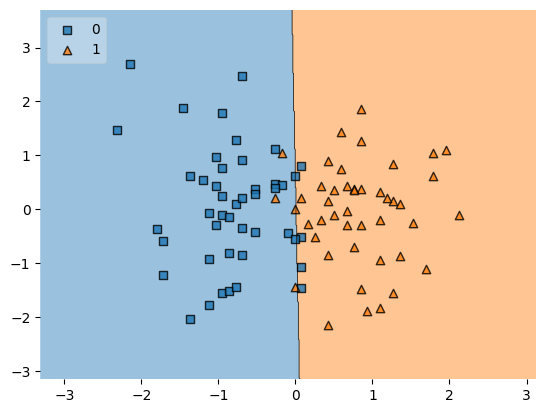

In [31]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.to_numpy(), clf=clf, legend=2)

In [1]:
import pickle

In [4]:
pickle.dump(clf, open('model.pkl', 'wb'))